## THIS NOTEBOOK TRAINS THE MODELS ON THE DATASET

For this nb, we will follow 3 models:
- First (baseline) model: **Logistic Regression**
- Second model: **Random Forest**
- Third model: **XGBoost**<br>

And compare the evaluation metrics and ouputs of all three models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, recall_score, log_loss, classification_report, confusion_matrix, roc_curve)


In [3]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv').squeeze()

Below is an evaluation function which we can call for each model

In [4]:
def evaluate_model(name, model, X, y):
    preds = model.predict(X)
    probs = model.predict_proba(X)[:, 1]
    
    return {
        'Model'            : name,
        'AUC-ROC'          : round(roc_auc_score(y, probs), 4),
        'F1 (Class 1)'     : round(f1_score(y, preds), 4),
        'Recall (Class 1)' : round(recall_score(y, preds), 4),
        'Log Loss'         : round(log_loss(y, probs), 4)
    }

In [59]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

xgb = XGBClassifier(n_estimators=175, 
                    random_state=42,
                    learning_rate=0.1,
                    eval_metric='logloss', 
                    verbosity=0,
                    subsample=0.9,
                    max_depth=5,
                    colsample_bytree=0.5,
                    )
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.5
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [60]:
results = []
results.append(evaluate_model('Logistic Regression', lr, X_val, y_val))
results.append(evaluate_model('Random Forest', rf, X_val, y_val))
results.append(evaluate_model('XGBoost', xgb, X_val, y_val))

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
results_df.to_csv('../outputs/model_comparison.csv', index=False)
results_df

,Model,AUC-ROC,F1 (Class 1),Recall (Class 1),Log Loss
2,XGBoost,0.9632,0.8052,0.9118,0.2274
1,Random Forest,0.9590,0.8205,0.9412,0.4716
0,Logistic Regression,0.8612,0.6667,0.8235,0.4762


## Model conclusion based on these metrics
**XGBoost** has the lowest logloss and best auc-roc score: thus standing out as the best model.

## Metrics visualization

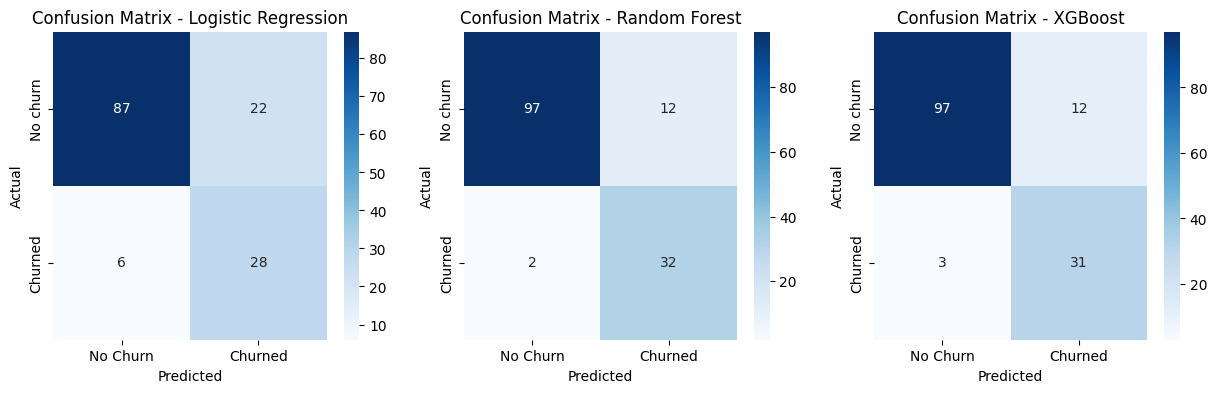

In [61]:
#Confusion Matrrix of each model (subplots 3 cols 1 row)
models = [lr, rf, xgb]
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
plt.figure(figsize=(15,4))
for i, (model, name) in enumerate(zip(models, model_names)):
    preds = model.predict(X_val)
    cm = confusion_matrix(y_val, preds)
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['No Churn', 'Churned'], yticklabels=['No churn', 'Churned'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.show()

### Confusion Matrices Evaluation
Even though Random forest and XGB are quite similar, and rf shows a better TPR and TNR, in a short dataset its difficult to justify. And, since RF has a higher **logloss** than XGB does, it ranks lower than the latter.

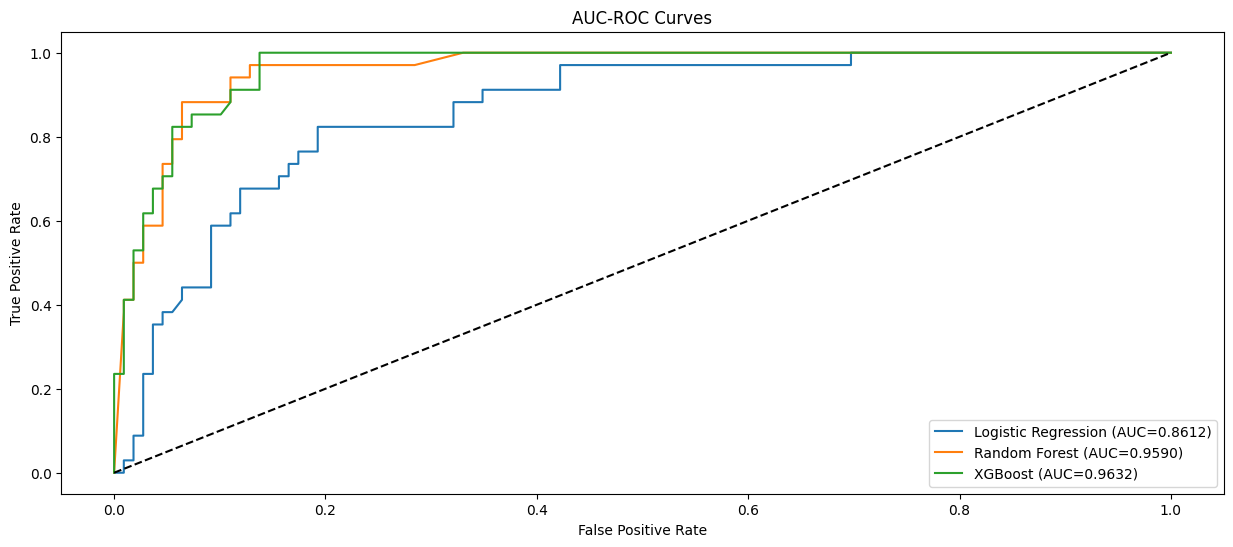

In [ ]:
#AUC-ROC Curves
plt.figure(figsize=(15,6))
for model, name in zip(models, model_names):
    probs = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, probs):.4f})')
plt.plot([0, 1], [0, 1], 'k--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curves')
plt.legend()
plt.savefig('../outputs/figures/auc_roc_curves.png', dpi=150)
plt.show()

### AUC-ROC Curvers Evaluation
As we can see, the XGBoost curves shows a higher true positive rate

#### Now lets do hyperparameter tuning for XGBoost using GridSearchCV
Will do this in two iterations to get the best output.

In [64]:
from sklearn.model_selection import RandomizedSearchCV

In [65]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)
print('Best params:', search.best_params_)
print('Best CV AUC-ROC:', round(search.best_score_, 4))

Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV AUC-ROC: 0.9699


In [66]:
best_xgb = search.best_estimator_
results.append(evaluate_model('XGBoost (Tuned)', best_xgb, X_val, y_val))

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
results_df

,Model,AUC-ROC,F1 (Class 1),Recall (Class 1),Log Loss
3,XGBoost (Tuned),0.9640,0.8000,0.8824,0.2283
2,XGBoost,0.9632,0.8052,0.9118,0.2274
1,Random Forest,0.9590,0.8205,0.9412,0.4716
0,Logistic Regression,0.8612,0.6667,0.8235,0.4762


### Observations after Best Parameter tuning
The log loss increased marginally, and the F1, Recall scores dropped. Thus, the initial XGBoost model can be named the best one and to be used further.

## Classification Report of the best model (Inital XGB)

In [70]:
# Best model on test set
best_model = xgb 

test_results = evaluate_model('XGBoost — TEST', best_model, X_test, y_test)

print(test_results)
print('\nClassification Report:')
report = classification_report(y_test, best_model.predict(X_test), target_names=['No Churn', 'Churned'], output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.round(4)

print(report_df)
report_df.to_csv('../outputs/classification_report.csv')

{'Model': 'XGBoost — TEST', 'AUC-ROC': 0.965, 'F1 (Class 1)': 0.8378, 'Recall (Class 1)': 0.9118, 'Log Loss': 0.202}

Classification Report:
              precision  recall  f1-score   support
No Churn         0.9712  0.9182    0.9439  110.0000
Churned          0.7750  0.9118    0.8378   34.0000
accuracy         0.9167  0.9167    0.9167    0.9167
macro avg        0.8731  0.9150    0.8909  144.0000
weighted avg     0.9248  0.9167    0.9189  144.0000


### Saving the model

In [69]:
joblib.dump(best_model, '../outputs/models/best_model.pkl')
print('Model saved.')

Model saved.
